In [1]:
from pathlib import Path
import os

root_path = Path("/mnt/jwh83-data/Confetti/output/Redsea/Clustering") 
data_path = root_path

output_dir = root_path
os.makedirs(output_dir, exist_ok=True)

print(f"Data path: {data_path}")
print(f"Output directory created at: {output_dir}")

Data path: /mnt/jwh83-data/Confetti/output/Redsea/Clustering
Output directory created at: /mnt/jwh83-data/Confetti/output/Redsea/Clustering


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore
from scipy.stats import norm
from scipy import stats
import scanpy as sc
import rapids_singlecell as rsc

/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from scipy.stats import zscore
def z_normalize(data, list_out, list_keep):
    """
    Normalize data by z-scoring and filter columns based on provided lists.

    Parameters:
        data (DataFrame): Input DataFrame containing data to be normalized.
        list_out (list): List of columns to be dropped from the DataFrame.
        list_keep (list): List of columns to be kept in the DataFrame but not normalized.

    Returns:
        DataFrame: DataFrame with columns normalized by z-score and filtered based on the provided lists.
    """
    # Drop columns containing 'blank' in their names and additional columns specified in list_out
    list1 = [col for col in data.columns if 'blank' in col]
    list_out1 = list1 + list_out
    dfin = data.drop(list_out1, axis=1)

    # Save columns specified in list_keep for later
    df_loc = dfin.loc[:, list_keep]

    # DataFrame for normalization (drop columns specified in list_keep)
    dfz = dfin.drop(list_keep, axis=1)

    # Calculate z-scores for the column markers
    dfz1 = pd.DataFrame(zscore(dfz, 0), index=dfz.index, columns=[i for i in dfz.columns])

    # Add back labels for normalization type
    dfz_all = pd.concat([dfz1, df_loc], axis=1, join='inner')

    # Print the number of unique File_ID
    # print("the number of File_IDs = " + str(len(dfz_all.File_ID.unique())))

    return dfz_all

In [4]:
def remove_noise(df, col_num, z_sum_thres, z_count_thres):
    """
    Remove noisy cells from the dataset based on specified thresholds.

    Parameters:
        df (DataFrame): Input DataFrame containing the dataset.
        col_num (int): Number of columns in the DataFrame to consider for noise removal.
        z_sum_thres (int): Threshold for the sum of z-scores.
        z_count_thres (int): Threshold for the count of values greater than 1.

    Returns:
        DataFrame: DataFrame with noisy cells removed.
        DataFrame: DataFrame containing removed noisy cells.
    """
    # Calculate count of values greater than 1 and sum of z-scores for each row
    df['Count'] = df.iloc[:, :col_num].ge(1).sum(axis=1)
    df['z_sum'] = df.iloc[:, :col_num].sum(axis=1)

    # Filter out noisy cells based on z_sum and Count thresholds
    cc = df[(df['z_sum'] > z_sum_thres) & (df['Count'] > z_count_thres)]
    df_want = df[~((df['z_sum'] > z_sum_thres) & (df['Count'] > z_count_thres))]

    # Calculate the percentage of removed noisy cells
    percent_removed = len(df_want) / len(df)
    print(str(percent_removed))

    # Plot histogram of cell counts
    ee = df['Count'].plot.hist(bins=50, alpha=0.8, logy=False)

    # Drop Count and z_sum columns and reset index for the filtered DataFrame
    df_want.drop(columns=['Count', 'z_sum'], inplace=True)
    df_want.reset_index(inplace=True, drop=True)

    return df_want, cc

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def nuclear_filter(data_in, nuc1_thres, nuc2_thres, save_path=None):
    """
    Plot scatter plot colored by donor_ID, filter data based on nuclear intensity thresholds.

    Parameters:
        data_in (DataFrame): Input DataFrame containing nuclear size and intensity data.
        nuc1_thres (float): Threshold value for Hoechst1 intensity.
        nuc2_thres (float): Threshold value for DRAQ5 intensity.

    Returns:
        DataFrame: Filtered DataFrame containing nuclei that meet the intensity criteria.
        DataFrame: DataFrame containing nuclei that do not meet the criteria.
    """
    # Sample a subset for plotting
    data_plot = data_in.sample(frac=0.1, random_state=42)

    # Create scatter plot colored by donor_ID
    plt.figure(figsize=(9, 5))
    g = sns.scatterplot(
        data=data_plot,
        x='Hoechst1',
        y='DRAQ5',
        hue='slide_name',
        palette='tab10',
        s=3,
        edgecolor=None
    )

    # Log-scale axes
    g.set_xscale('log')
    g.set_yscale('log')
    ticks = [100, 1000, 10000, 100000]
    g.set_xticks(ticks)
    g.set_xticklabels(ticks, fontsize=10)
    g.set_yticks(ticks)
    g.set_yticklabels(ticks, fontsize=10)

    # Axes labels
    g.set_xlabel('Hoechst1 Intensity', fontsize=14)
    g.set_ylabel('DRAQ5 Intensity', fontsize=14)
    g.set_title('Nuclear Intensity Filter', fontsize=16)

    # Threshold lines
    plt.axvline(x=nuc1_thres, color='red', linestyle='--', linewidth=1.5)
    plt.axhline(y=nuc2_thres, color='red', linestyle='--', linewidth=1.5)

    # Legend formatting
    plt.legend(title='sample_ID', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12, title_fontsize=13)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
            
    plt.show()

    # Filtering logic
    df_nuc = data_in[(data_in['Hoechst1'] > nuc1_thres) | (data_in['DRAQ5'] > nuc2_thres)]
    nuc_cc = data_in[~((data_in['Hoechst1'] > nuc1_thres) | (data_in['DRAQ5'] > nuc2_thres))]

    per_keep = len(df_nuc) / len(data_in)
    print(f"Percentage of data kept: {per_keep:.2%}")

    return df_nuc, nuc_cc


In [6]:
def area_filter(data_in, size_min, size_max):
    """
    Plot scatter plot by region, filter data based on size thresholds.

    Parameters:
        data_in (DataFrame): Input DataFrame containing nuclear size and intensity data.
        size_min (float): Minimum nuclear size threshold.
        size_max (float): Maximum nuclear size threshold.

    Returns:
        DataFrame: Filtered DataFrame containing nuclei that meet the size criteria.
    """
    # Plot scatter plot by region
    plt.figure(figsize=(7, 7))
    data_plot = data_in.sample(frac=0.05, random_state=42)
    g = sns.scatterplot(
        data=data_plot,
        x='cell_size',
        y='Hoechst1',
        hue='slide_name',
        s=10,  # fixed marker size
        legend='full'  # only hue legend
    )

    g.set_xscale('log')
    g.set_yscale('log')
    ticks = [10, 100, 1000, 10000, 100000]
    g.set_yticks(ticks)
    g.set_yticklabels(ticks)
    g.set_xticks(ticks)
    g.set_xticklabels(ticks)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

    # Add vertical lines for min & max thresholds
    plt.axvline(x=size_min, color='red', linestyle='--', label=f"Min size = {size_min}")
    plt.axvline(x=size_max, color='blue', linestyle='--', label=f"Max size = {size_max}")
    plt.legend()

    # Filter data based on min & max size thresholds
    df_area = data_in[(data_in['cell_size'] > size_min) & (data_in['cell_size'] < size_max)]
    per_keep = len(df_area) / len(data_in)
    print(f"Fraction kept: {per_keep:.2%}")

    return df_area


In [7]:
import scanpy as sc
import pandas as pd

def get_adata(data: pd.DataFrame, list_out: list):
    """
    Convert DataFrame to AnnData format.

    Parameters:
        data (DataFrame): Input DataFrame containing data to be converted.
        list_out (list): List of columns to be included in adata.X (i.e., feature matrix).

    Returns:
        AnnData: AnnData object with list_out columns in X and remaining columns in .obs.
    """
    data = data.reset_index(drop=True)

    # Split data into X and obs parts
    X = data[list_out]
    obs = data.drop(columns=list_out)

    # Create AnnData
    adata = sc.AnnData(X)
    adata.obs = obs

    return adata


In [8]:
df = pd.read_csv(output_dir / "CellSAM_single_cell_before_redsea_All.csv")
df

,Unnamed: 0,CellID,cell_size,Hoechst1,MUC2,SOX9,MUC6,MUC1,GATA3,CD31,...,Ki67,CD49a,CD163,CD161,CD294,DRAQ5,x_centroid,y_centroid,slide_name,FILE
0,0.0,B004-A-004_1,675.0,2064.854815,54.882963,211.804444,2.450370,424.374815,433.604444,1649.672593,...,418.487407,2673.262222,37423.050370,36.250370,261.872593,367.925926,277.500741,165.874074,B004-A-004,single_cell_before_redsea.csv
1,1.0,B004-A-004_2,540.0,1607.020370,45.851852,215.396296,4.790741,287.535185,533.448148,1800.548148,...,237.416667,2957.066667,13078.185185,234.194444,211.050000,403.607407,262.031481,140.451852,B004-A-004,single_cell_before_redsea.csv
2,2.0,B004-A-004_3,136.0,1620.441176,201.022059,826.441176,3.617647,503.279412,301.198529,6.676471,...,549.323529,15491.764706,312.669118,287.088235,61.117647,312.176471,321.764706,140.830882,B004-A-004,single_cell_before_redsea.csv
3,3.0,B004-A-004_4,193.0,1415.113990,281.305699,986.559585,1.730570,493.461140,339.844560,2.989637,...,171.435233,8207.549223,38.202073,120.689119,23.000000,111.792746,22.777202,339.730570,B004-A-004,single_cell_before_redsea.csv
4,4.0,B004-A-004_5,95.0,1251.294737,195.378947,1111.442105,1.315789,357.126316,253.684211,1.757895,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.589474,325.884211,B004-A-004,single_cell_before_redsea.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200273,37662.0,B004-A-504_37663,266.0,3465.394737,0.112782,13.146617,3.857143,210.687970,181.887218,3.684211,...,93.041353,302.511278,37.567669,29.796992,52.432331,647.620301,2755.120301,9912.018797,B004-A-504,single_cell_before_redsea.csv
200274,37663.0,B004-A-504_37664,362.0,4584.140884,0.000000,31.533149,2.577348,326.839779,854.933702,3.469613,...,120.229282,1727.953039,68.447514,38.709945,68.770718,1092.906077,2592.146409,9807.991713,B004-A-504,single_cell_before_redsea.csv
200275,37664.0,B004-A-504_37665,540.0,1793.155556,0.070370,27.155556,3.290741,297.203704,329.937037,2.944444,...,142.912963,1023.435185,32.855556,31.625926,53.440741,324.824074,2659.083333,9909.329630,B004-A-504,single_cell_before_redsea.csv
200276,37665.0,B004-A-504_37666,1652.0,6417.465496,0.000000,30.661622,2.964891,274.562349,217.393462,2.907990,...,109.943705,439.331114,37.362591,38.776634,56.352300,1508.335956,2810.687651,9913.457627,B004-A-504,single_cell_before_redsea.csv


In [9]:
df.columns

Index(['Unnamed: 0', 'CellID', 'cell_size', 'Hoechst1', 'MUC2', 'SOX9', 'MUC6',
       'MUC1', 'GATA3', 'CD31', 'Synapto', 'Lefty', 'CD49f', 'CD15', 'CHGA',
       'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c',
       'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'CD279', 'aSMA',
       'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5',
       'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CK7', 'CollIV',
       'CD117', 'PGP95', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'CD154',
       'Somatostatin', 'Ki67', 'CD49a', 'CD163', 'CD161', 'CD294', 'DRAQ5',
       'x_centroid', 'y_centroid', 'slide_name', 'FILE'],
      dtype='object')

In [10]:
list_keep = [
        'Unnamed: 0', 'CellID', 'cell_size','DRAQ5',
       'x_centroid', 'y_centroid', 'slide_name', 'FILE', 'Hoechst1'
        ]
df = z_normalize(df, list_keep = list_keep, list_out = [])

In [11]:
num_rows = len(df)
print(f"Number of rows: {num_rows}")

Number of rows: 200278


In [12]:
df.columns

Index(['MUC2', 'SOX9', 'MUC6', 'MUC1', 'GATA3', 'CD31', 'Synapto', 'Lefty',
       'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin',
       'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38',
       'CD90', 'CD279', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206',
       'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO',
       'Cytokeratin', 'CK7', 'CollIV', 'CD117', 'PGP95', 'CD19', 'Podoplanin',
       'CD45', 'CD56', 'CD69', 'CD154', 'Somatostatin', 'Ki67', 'CD49a',
       'CD163', 'CD161', 'CD294', 'Unnamed: 0', 'CellID', 'cell_size', 'DRAQ5',
       'x_centroid', 'y_centroid', 'slide_name', 'FILE', 'Hoechst1'],
      dtype='object')

In [13]:
standardize_dict = {
    'aDef5': 'aDefensin5',
    'collagen IV': 'CollagenIV',
    'CollIV': 'CollagenIV',
    'cytokeratin': 'Cytokeratin',
    'HOECHST1': 'Hoechst1',
    'podoplanin': 'Podoplanin',
    'HLADR': 'HLA-DR',
    'Synapt': 'Synaptophysin',
    'Synapto': 'Synaptophysin',
    'PDPN': 'Podoplanin'
} 
df = df.rename(columns=standardize_dict)

In [14]:
priority_cols = [
       'CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31',
       'CD123', 'CDX2'
]

meta_cols = [
    'slide_name', 'CellID', 'Unnamed: 0', 'cell_size',
    'x_centroid', 'y_centroid', 'FILE',
]

# Keep columns not in either list
remaining_cols = [col for col in df.columns if col not in priority_cols + meta_cols]

# Reorder dataframe
df = df[priority_cols + meta_cols + remaining_cols]


In [15]:
df.columns

Index(['CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31',
       'CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size',
       'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279',
       'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5',
       'Hoechst1'],
      dtype='object')

In [16]:
marker_number = df.columns.get_loc('slide_name')
marker_number

47

0.986818322531681


/tmp/ipykernel_428242/2719099457.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_want.drop(columns=['Count', 'z_sum'], inplace=True)


,CD45RO,CD56,CD15,CD163,MUC2,CD34,CD36,aDefensin5,CD49a,HLA-DR,...,Lefty,CD279,NKG2D,CK7,PGP95,CD154,Somatostatin,CD294,DRAQ5,Hoechst1
0,0.382848,-0.346716,-0.398557,11.526780,-0.295752,-0.410009,-0.341983,0.068159,-0.562289,-0.278968,...,-0.251325,-0.475136,-0.255219,-0.213804,-0.270359,-0.207770,-0.234655,-0.181518,367.925926,2064.854815
1,-0.215198,-0.328861,-0.397176,3.690375,-0.301630,-0.372224,-0.267977,-0.121661,-0.525529,-0.258033,...,-0.210681,-0.459222,-0.235134,-0.195370,-0.263586,-0.198746,-0.142979,-0.211843,403.607407,1607.020370
2,-0.450575,-0.300929,-0.398644,-0.418736,-0.200649,-0.353638,-0.317147,-0.172267,1.098023,-0.488742,...,0.357514,-0.471035,-0.241344,-0.257760,-0.242679,-0.199224,-0.227672,-0.301304,312.176471,1620.441176
3,-0.645454,-0.364468,-0.398644,-0.507085,-0.148403,-0.394134,-0.339609,-0.176737,0.154538,-0.505039,...,0.326093,-0.476332,-0.251109,-0.264243,-0.306892,-0.212029,-0.326051,-0.324047,111.792746,1415.113990
4,-0.840214,-0.417089,-0.398644,-0.519382,-0.204322,-0.485409,-0.354856,-0.177066,-0.908542,-0.596327,...,0.066527,-0.510171,-0.274475,-0.265886,-0.359970,-0.215988,-0.381378,-0.337771,0.000000,1251.294737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197633,-0.648315,-0.411617,-0.394667,-0.507289,-0.331395,-0.403923,-0.338505,-0.172955,-0.869359,-0.539221,...,-0.264132,-0.478607,-0.249378,-0.256056,-0.328362,-0.200469,-0.327145,-0.306486,647.620301,3465.394737
197634,-0.320333,-0.412592,-0.398644,-0.497349,-0.331469,-0.383534,-0.298273,-0.172752,-0.684730,-0.261424,...,-0.263757,-0.464990,-0.221690,-0.259556,-0.316074,-0.197616,-0.287652,-0.296737,1092.906077,4584.140884
197635,-0.486533,-0.411805,-0.380248,-0.508806,-0.331423,-0.390257,-0.326575,-0.173449,-0.775982,-0.518998,...,-0.261919,-0.472484,-0.225006,-0.257888,-0.323403,-0.197352,-0.304883,-0.305884,324.824074,1793.155556
197636,-0.563157,-0.412794,-0.398241,-0.507355,-0.331469,-0.389985,-0.337854,-0.173226,-0.851638,-0.501767,...,-0.256735,-0.473817,-0.252722,-0.259514,-0.322972,-0.205328,-0.313414,-0.304147,1508.335956,6417.465496


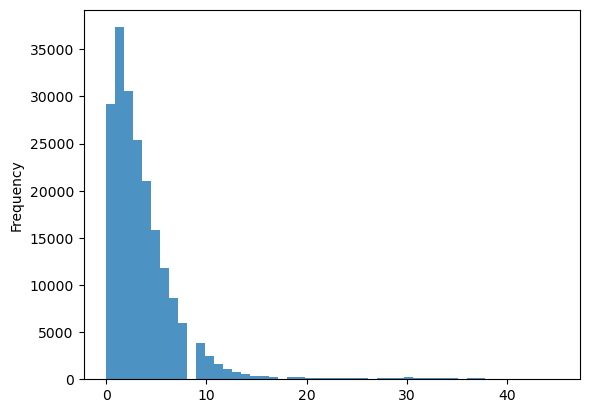

In [17]:
df_nn,cc = remove_noise(df=df, col_num=marker_number, z_sum_thres=20, z_count_thres=20)
df_nn

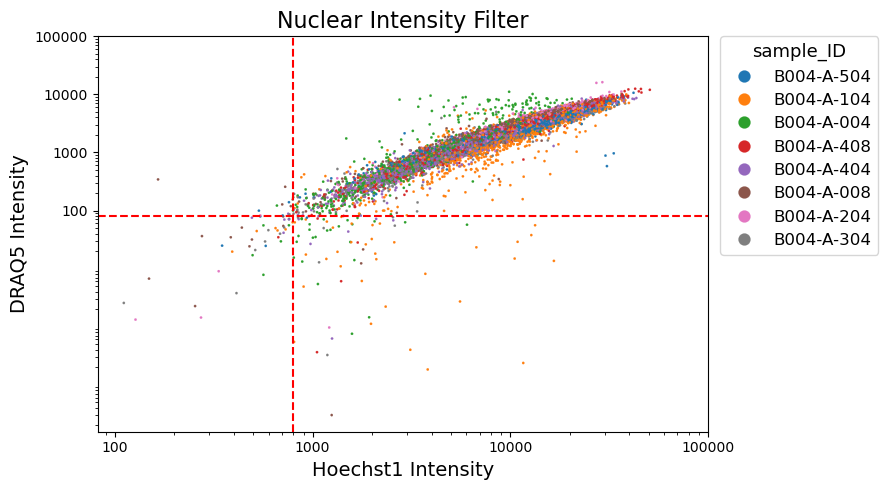

Percentage of data kept: 99.76%


In [18]:
plt.rcParams["legend.markerscale"] = 5
df_nuc, nuc_cc = nuclear_filter(df_nn, 800, 80)

In [19]:
df_nuc['slide_name'].unique()

array(['B004-A-004', 'B004-A-008', 'B004-A-104', 'B004-A-204',
       'B004-A-304', 'B004-A-404', 'B004-A-408', 'B004-A-504'],
      dtype=object)

Fraction kept: 99.29%


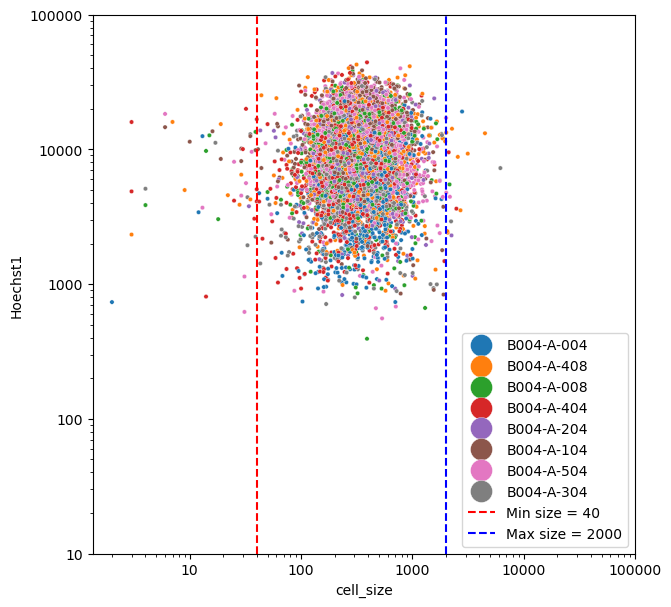

In [20]:
plt.rcParams["legend.markerscale"] = 5
df_area = area_filter(df_nuc, size_min=40, size_max=2000)

In [21]:
df_area.columns

Index(['CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31',
       'CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size',
       'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279',
       'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5',
       'Hoechst1'],
      dtype='object')

In [22]:
list_out = [ 
       'CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31'
]

#adata = get_adata(data = df_nn, list_keep_obs = list_keep)

adata = get_adata(data = df_area, list_out = list_out)
adata

/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 195752 × 45
    obs: 'CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size', 'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279', 'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5', 'Hoechst1'

In [23]:
adata.var_names

Index(['CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31'],
      dtype='object')

In [24]:
adata.obs.columns

Index(['CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size',
       'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279',
       'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5',
       'Hoechst1'],
      dtype='object')

In [25]:
adata.var_names

Index(['CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5',
       'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44',
       'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161',
       'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA',
       'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c',
       'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31'],
      dtype='object')

In [26]:
rsc.tl.pca(adata)

In [27]:
rsc.pp.neighbors(adata=adata, n_neighbors=30, n_pcs=None, use_rep='X_pca')

In [28]:
rsc.tl.leiden(adata=adata, resolution=1.5, n_iterations=100, key_added='leiden')

In [29]:
len(adata.obs['leiden'].unique())

40

In [30]:
# This code can help order the markers

marker_list = list(adata.var_names)
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

# Subset AnnData to include only your markers
adata_bi = adata[:, marker_list] 

# Calculate the mean expression for each marker in each cluster
mean_expression = sc.get.obs_df(adata, keys=marker_list + ['leiden'])
mean_expression_pivot = mean_expression.groupby('leiden').mean().T

# Perform hierarchical clustering on the markers
marker_expression = mean_expression_pivot.values  # Extract mean expression values
linkage_matrix = linkage(marker_expression, method='ward', metric='euclidean')
dendro = dendrogram(linkage_matrix, labels=mean_expression_pivot.index, no_plot=True)
ordered_markers = [mean_expression_pivot.index[i] for i in leaves_list(linkage_matrix)]

# Reorder markers in the AnnData object
adata_bi = adata[:, ordered_markers] 

/tmp/ipykernel_428242/2469779795.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expression_pivot = mean_expression.groupby('leiden').mean().T


/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
... storing 'slide_name' as categorical
/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'FILE' as categorical


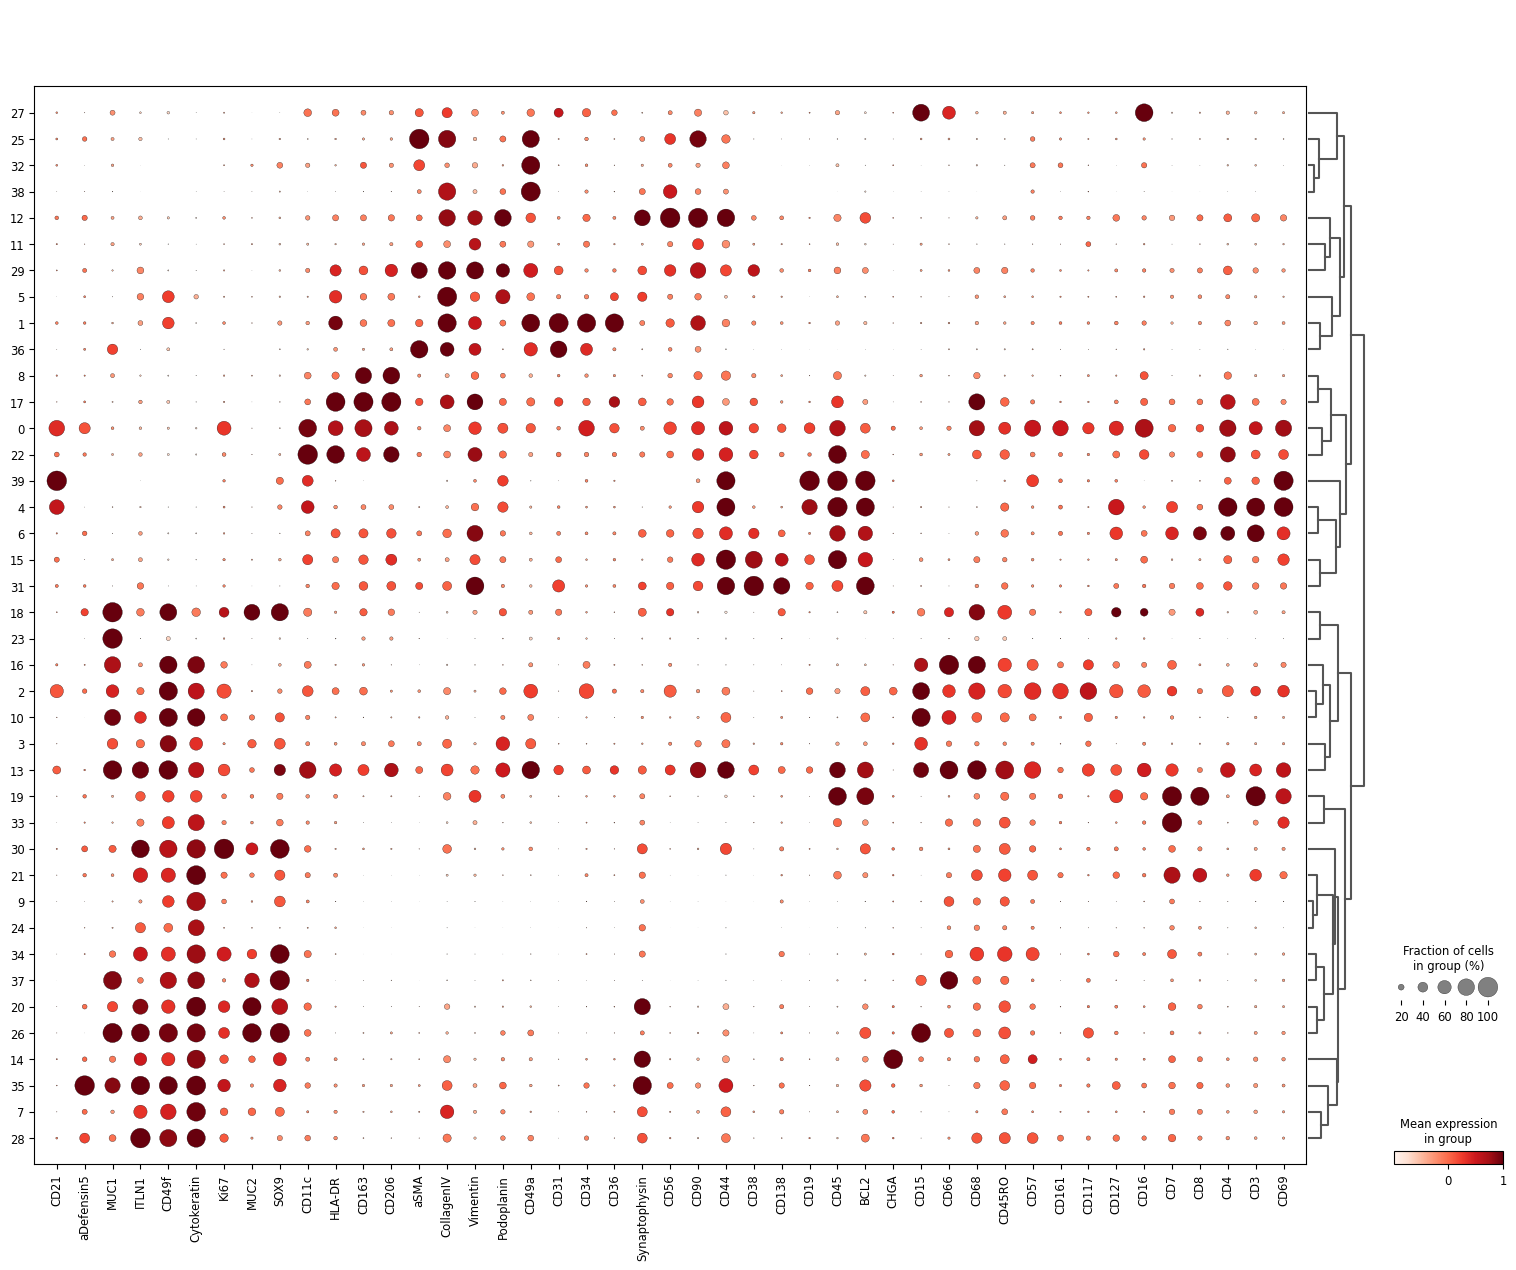

In [31]:
sc.pl.dotplot(adata_bi, ordered_markers, groupby='leiden', 
              vmax=1, expression_cutoff=0.1, dendrogram=True, swap_axes=False, save=False)

In [32]:
adata

AnnData object with n_obs × n_vars = 195752 × 45
    obs: 'CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size', 'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279', 'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5', 'Hoechst1', 'leiden'
    uns: 'pca', 'neighbors', 'leiden'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [33]:
adata.write_h5ad(output_dir / "cellSAM_beforeREDSEA_leiden.h5ad")

... storing 'slide_name' as categorical


... storing 'FILE' as categorical


In [34]:
adata.obs['leiden'].value_counts(sort=True)

leiden
6     12649
7      9595
26     9540
15     9500
1      9330
31     9040
10     8714
8      8431
21     7302
4      6956
24     6825
20     6444
25     6154
2      6123
16     6056
0      5739
9      5737
11     5304
17     4935
12     4373
37     4339
32     3952
19     3440
3      3410
29     3262
36     3149
34     2982
38     2961
5      2470
33     2323
13     2221
27     2089
28     1960
22     1868
14     1767
23     1449
35     1358
39      689
18      672
30      644
Name: count, dtype: int64